# Notebook de Optimización: Método de Falsa Posición

Este cuaderno implementa el método de optimización de Falsa Posición (Regla Falsa) para encontrar el mínimo de una función unimodal dentro de un intervalo especificado. Además, visualiza la función con el punto óptimo encontrado y la convergencia del error a lo largo de las iteraciones.

## ¿Qué es el Método de Falsa Posición para Optimización?

En optimización de una variable, el método de Falsa Posición se aplica sobre la derivada de la función para encontrar un punto estacionario, es decir, una solución de `f'(x) = 0`. Si la función es unimodal en el intervalo, ese punto corresponde al mínimo buscado.

El algoritmo funciona de la siguiente manera para encontrar un mínimo en el intervalo `[a, b]`:

1. Se verifica que `f'(a)` y `f'(b)` tengan signos opuestos, garantizando una raíz de la derivada en el intervalo.
2. Se calcula una aproximación `x_r` por interpolación lineal entre `(a, f'(a))` y `(b, f'(b))`.
3. Se evalúa `f'(x_r)`.
4. Si `f'(x_r)` es suficientemente cercano a cero, se detiene el proceso.
5. Si `f'(a)` y `f'(x_r)` tienen signos opuestos, se actualiza `b = x_r`; en caso contrario, `a = x_r`.
6. Se repite hasta que el tamaño del intervalo sea menor que una tolerancia definida.

La principal diferencia respecto a Bisección es que aquí no se usa el punto medio, sino una estimación lineal que suele mejorar la aproximación en muchos casos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import inspect

In [7]:
def funcion_ejemplo(x):
    return x**3 - x**2 -10

def derivada_numerica_central(func, x, h=1e-6):
    """Aproxima la derivada usando diferencias centrales."""
    return (func(x + h) - func(x - h)) / (2 * h)

# Si quisieras probar con otra función, por ejemplo:
# def funcion_ejemplo(x):
#     return x**4 - 3*x**3 + 2

In [11]:
def falsa_posicion_minimizacion(func, a, b, tol=1e-5, max_iter=1000, h_deriv=1e-6):
    if a >= b:
        raise ValueError("El intervalo debe cumplir a < b.")

    dfa = derivada_numerica_central(func, a, h_deriv)
    dfb = derivada_numerica_central(func, b, h_deriv)

    historial_error = []
    xr_anterior = None  # Variable para rastrear el valor previo

    for i in range(max_iter):
        denominador = (dfb - dfa)
        
        if abs(denominador) < 1e-15:
            xr = (a + b) / 2
        else:
            xr = b - dfb * (b - a) / denominador

        # Calcular el error relativo o absoluto respecto al xr anterior
        if xr_anterior is not None:
            error_actual = abs(xr - xr_anterior)
            historial_error.append((i, error_actual))
        
        dfxr = derivada_numerica_central(func, xr, h_deriv)

        # Criterios de parada
        if abs(dfxr) < tol or (xr_anterior is not None and abs(xr - xr_anterior) < tol):
            break

        # Actualización de límites (Paso 3 del algoritmo)
        if dfa * dfxr < 0:
            b = xr
            dfb = dfxr
        else:
            a = xr
            dfa = dfxr
        
        # Guardar el xr actual para la siguiente iteración
        xr_anterior = xr

    x_opt = xr
    f_opt = func(x_opt)
    return x_opt, f_opt, historial_error

def falsa_posicion_maximizacion(func, a, b, tol=1e-5, max_iter=1000, h_deriv=1e-6):
    """Encuentra un máximo minimizando -f(x)."""
    def neg_func(x):
        return -func(x)

    x_opt, neg_f_opt, historial_error = falsa_posicion_minimizacion(
        neg_func, a, b, tol=tol, max_iter=max_iter, h_deriv=h_deriv
    )
    return x_opt, -neg_f_opt, historial_error

In [12]:
# Definir el intervalo inicial de búsqueda
a_intervalo = -10
b_intervalo = 10
fn= inspect.getsource(funcion_ejemplo).split("return")[-1].strip()
# Definir la tolerancia
tolerancia = 1e-6

print(f"Buscando el mínimo de la función f(x) = {fn} en el intervalo [{a_intervalo}, {b_intervalo}]")
print(f"Con una tolerancia de {tolerancia}\n")

x_min_encontrado, f_min_encontrado, historial_error_min = falsa_posicion_minimizacion(
    funcion_ejemplo, a_intervalo, b_intervalo, tol=tolerancia
)

print(f"Mínimo encontrado en x = {x_min_encontrado:.6f}")
print(f"Valor de la función en el mínimo = {f_min_encontrado:.6f}")
print(f"Número de iteraciones: {len(historial_error_min) - 1}")
print(f"Error final (tamaño del intervalo) = {historial_error_min[-1][1]:.6e}\n")

# Si quisieras buscar un máximo:
# def funcion_ejemplo_max(x):
#     return -(x - 2)**2 + 5
# x_max_encontrado, f_max_encontrado, historial_error_max = falsa_posicion_maximizacion(
#     funcion_ejemplo_max, a_intervalo, b_intervalo, tol=tolerancia
# )
# print(f"Máximo encontrado en x = {x_max_encontrado:.6f}")
# print(f"Valor de la función en el máximo = {f_max_encontrado:.6f}")

Buscando el mínimo de la función f(x) = x**3 - x**2 -10 en el intervalo [-10, 10]
Con una tolerancia de 1e-06

Mínimo encontrado en x = 0.666680
Valor de la función en el mínimo = -10.148148
Número de iteraciones: 156
Error final (tamaño del intervalo) = 9.367605e-07



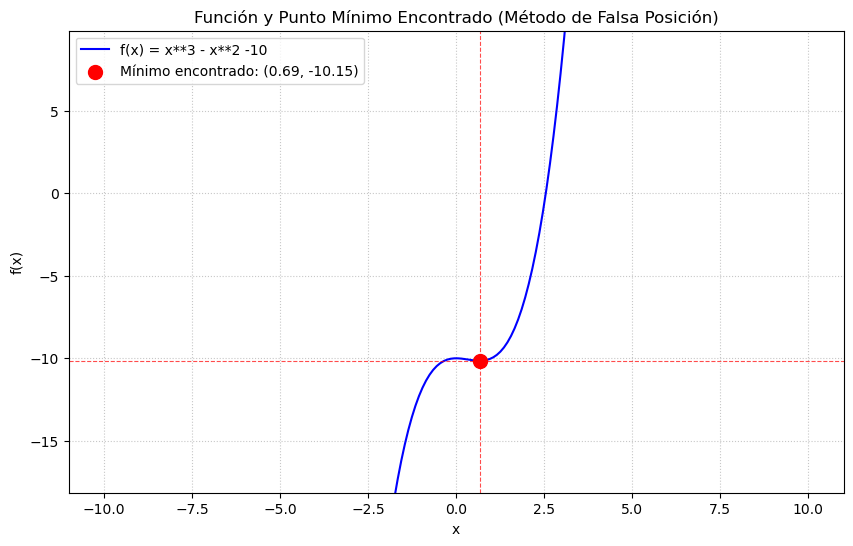

In [9]:
# Generar puntos para graficar la función
x_vals = np.linspace(a_intervalo, b_intervalo, 200)
y_vals=[]
for val in x_vals:
    y_vals.append(funcion_ejemplo(val))


plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label='f(x) = '+fn, color='blue')
plt.scatter(
    x_min_encontrado,
    f_min_encontrado,
    color='red',
    marker='o',
    s=100,
    label=f'Mínimo encontrado: ({x_min_encontrado:.2f}, {f_min_encontrado:.2f})',
    zorder=5
)
plt.axvline(x=x_min_encontrado, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
plt.axhline(y=f_min_encontrado, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
plt.ylim(f_min_encontrado - 8, f_min_encontrado + 20)
plt.title('Función y Punto Mínimo Encontrado (Método de Falsa Posición)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

<>:13: SyntaxWarning: invalid escape sequence '\_'
<>:13: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_20056/1110863613.py:13: SyntaxWarning: invalid escape sequence '\_'
  plt.ylabel('Error $|x_r - x_{r\_prev}|$ (escala log)')


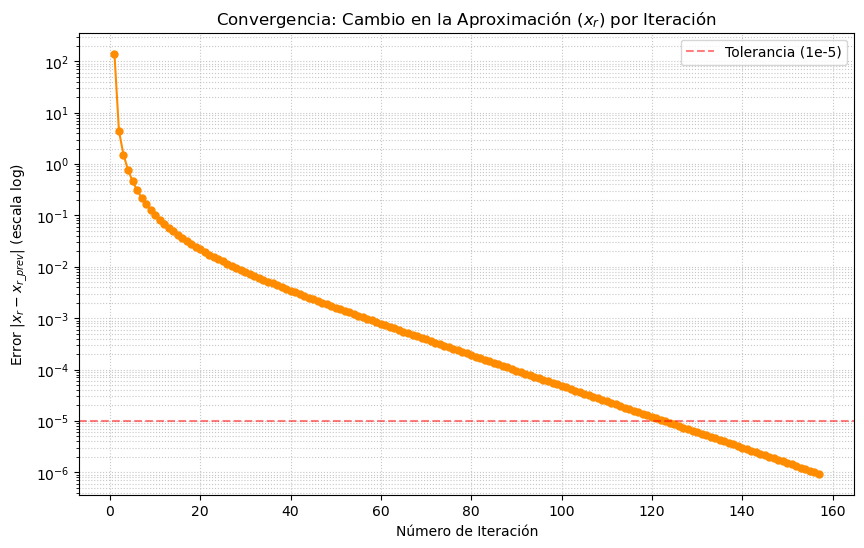

--- Historial de Convergencia ---
 Iteración  Cambio en xr
         1    140.585774
         2      4.392652
         3      1.523416
         4      0.771930
         5      0.465592
         6      0.310798
         7      0.221744
         8      0.165824
         9      0.128417
        10      0.102165
...
 Iteración  Cambio en xr
       153  1.234536e-06
       154  1.152232e-06
       155  1.075375e-06
       156  1.003699e-06
       157  9.367605e-07


In [13]:
# 1. Extraer las iteraciones y el cambio en xr del historial
# Ahora item[1] representa abs(xr - xr_anterior)
iteraciones = [item[0] for item in historial_error_min]
errores = [item[1] for item in historial_error_min]

plt.figure(figsize=(10, 6))
# Graficamos el error en escala logarítmica
plt.plot(iteraciones, errores, marker='o', linestyle='-', color='darkorange', markersize=5)

plt.yscale('log') # Esencial para ver la convergencia en métodos numéricos
plt.title('Convergencia: Cambio en la Aproximación ($x_r$) por Iteración')
plt.xlabel('Número de Iteración')
plt.ylabel('Error $|x_r - x_{r\_prev}|$ (escala log)')
plt.grid(True, which="both", linestyle=':', alpha=0.7)

# Añadir una línea de referencia para la tolerancia
plt.axhline(y=1e-5, color='red', linestyle='--', alpha=0.5, label='Tolerancia (1e-5)')
plt.legend()
plt.show()

# 2. Modificación de la Tabla (DataFrame)
df_error = pd.DataFrame(historial_error_min, columns=['Iteración', 'Cambio en xr'])
print('--- Historial de Convergencia ---')
print(df_error.head(10).to_string(index=False))
print('...')
print(df_error.tail(5).to_string(index=False))

In [15]:
# Tabla de iteraciones, valores y error
print('Tabla de iteraciones (valores y error):')

if 'historial_raiz' in globals() and historial_raiz:
    tabla = pd.DataFrame(historial_raiz, columns=['Iteracion', 'x_k', 'g(x_k)', 'Error'])
    print(tabla.to_string(index=False))
elif 'historial' in globals() and historial:
    n_cols = len(historial[0])
    if n_cols == 9:
        tabla = pd.DataFrame(historial, columns=['Iteracion', 'x_k', 'y_k', 'f(x_k,y_k)', 'df_dx', 'df_dy', 'h_opt', 'Error_paso', 'Norma_gradiente'])
    elif n_cols == 4:
        tabla = pd.DataFrame(historial, columns=['Iteracion', 'x_k', 'g(x_k)', 'Error'])
    elif n_cols == 2:
        tabla = pd.DataFrame(historial, columns=['Iteracion', 'Error'])
    else:
        tabla = pd.DataFrame(historial)
    print(tabla.to_string(index=False))
elif 'historial_error_min' in globals() and historial_error_min:
    tabla = pd.DataFrame(historial_error_min, columns=['Iteracion', 'Error'])
    print(tabla.to_string(index=False))
elif 'historial_error' in globals() and historial_error:
    tabla = pd.DataFrame(historial_error, columns=['Iteracion', 'Error'])
    print(tabla.to_string(index=False))
else:
    print('No se encontro una variable de historial para construir la tabla.')

Tabla de iteraciones (valores y error):
 Iteracion        Error
         1 1.405858e+02
         2 4.392652e+00
         3 1.523416e+00
         4 7.719295e-01
         5 4.655922e-01
         6 3.107984e-01
         7 2.217442e-01
         8 1.658237e-01
         9 1.284165e-01
        10 1.021655e-01
        11 8.303799e-02
        12 6.867280e-02
        13 5.761226e-02
        14 4.891692e-02
        15 4.195912e-02
        16 3.630654e-02
        17 3.165350e-02
        18 2.777894e-02
        19 2.451974e-02
        20 2.175342e-02
        21 1.938655e-02
        22 1.734686e-02
        23 1.557775e-02
        24 1.403435e-02
        25 1.268073e-02
        26 1.148784e-02
        27 1.043199e-02
        28 9.493705e-03
        29 8.656832e-03
        30 7.907910e-03
        31 7.235632e-03
        32 6.630444e-03
        33 6.084230e-03
        34 5.590059e-03
        35 5.141979e-03
        36 4.734858e-03
        37 4.364253e-03
        38 4.026295e-03
        39 3.717608e-03
